## 1. Exploración de Datos para Forecasting

### Objetivo
Explorar los tres archivos de datos proporcionados por DSMarket (ventas, calendario y precios) para entender su estructura, calidad y características antes de cualquier transformación.

### Contexto de negocio
DSMarket necesita mejorar sus predicciones de ventas a nivel tienda-producto. Antes de construir modelos predictivos, debemos conocer en profundidad los datos disponibles: qué información contienen, su calidad, posibles problemas y relaciones entre tablas.

### Qué se consigue al finalizar
- Comprensión clara de la estructura de cada archivo
- Identificación de valores nulos, duplicados y anomalías
- Conocimiento de los rangos temporales y dimensiones del problema
- Base sólida para la preparación de datos en el siguiente notebook

## 2. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Ignorar warnings innecesarios
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 3. Carga de datos

Cargamos los tres archivos CSV desde sus rutas originales sin moverlos ni copiarlos.

In [2]:
# Rutas de los archivos (no mover ni copiar los CSV)
ITEM_SALES = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/raw/item_sales.csv')
CALENDAR = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/raw/daily_calendar_with_events.csv')
ITEM_PRICES = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/raw/item_prices.csv')

print("Datos cargados correctamente")
print(f"- item_sales: {ITEM_SALES.shape[0]:,} filas x {ITEM_SALES.shape[1]} columnas")
print(f"- calendar: {CALENDAR.shape[0]:,} filas x {CALENDAR.shape[1]} columnas")
print(f"- item_prices: {ITEM_PRICES.shape[0]:,} filas x {ITEM_PRICES.shape[1]} columnas")

Datos cargados correctamente
- item_sales: 30,490 filas x 1920 columnas
- calendar: 1,913 filas x 5 columnas
- item_prices: 6,965,706 filas x 5 columnas


## 4. Exploración de `item_sales`

Este archivo contiene las ventas diarias por producto y tienda. Según el enunciado:
- `id`: identificador de serie (combinación item + store_code)
- `item`: id del producto
- `category`: categoría del producto
- `department`: departamento
- `store`, `store_code`, `region`: información de la tienda
- `d_1, d_2, ...`: unidades vendidas por día

In [3]:
# Dimensiones y primeras filas
print("="*60)
print("DIMENSIONES DE ITEM_SALES")
print("="*60)
print(f"Filas: {ITEM_SALES.shape[0]:,}")
print(f"Columnas: {ITEM_SALES.shape[1]}")
print()

# Primeras filas
ITEM_SALES.head()

DIMENSIONES DE ITEM_SALES
Filas: 30,490
Columnas: 1920



id              item    category    department  \
0  ACCESORIES_1_001_NYC_1  ACCESORIES_1_001  ACCESORIES  ACCESORIES_1   
1  ACCESORIES_1_002_NYC_1  ACCESORIES_1_002  ACCESORIES  ACCESORIES_1   
2  ACCESORIES_1_003_NYC_1  ACCESORIES_1_003  ACCESORIES  ACCESORIES_1   
3  ACCESORIES_1_004_NYC_1  ACCESORIES_1_004  ACCESORIES  ACCESORIES_1   
4  ACCESORIES_1_005_NYC_1  ACCESORIES_1_005  ACCESORIES  ACCESORIES_1   

               store store_code    region  d_1  d_2  d_3  d_4  d_5  d_6  d_7  \
0  Greenwich_Village      NYC_1  New York    0    0    0    0    0    0    0   
1  Greenwich_Village      NYC_1  New York    0    0    0    0    0    0    0   
2  Greenwich_Village      NYC_1  New York    0    0    0    0    0    0    0   
3  Greenwich_Village      NYC_1  New York    0    0    0    0    0    0    0   
4  Greenwich_Village      NYC_1  New York    0    0    0    0    0    0    0   

   d_8  d_9  d_10  d_11  d_12  d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  \
0    0    0     0     0     0     0     0     0     0     0     0     0     0   
1    0    0     0     0     0     0     0     0     0     0     0     0     0   
2    0    0     0     0     0     0     0     0     0     0     0     0     0   
3    0    0     0     0     0     0     0     0     0     0     0     0     0   
4    0    0     0     0     0     0     0     0     0     0     0     0     0   

   d_21  d_22  d_23  d_24  d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_33  d_34  d_35  d_36  d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     2     0     0     0     2     0     1     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_45  d_46  d_47  d_48  d_49  d_50  d_51  d_52  d_53  d_54  d_55  d_56  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     2     0     1     0     0     1     1   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_57  d_58  d_59  d_60  d_61  d_62  d_63  d_64  d_65  d_66  d_67  d_68  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     1     0     2     3     1     0     0     0     0     0     1     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_69  d_70  d_71  d_72  d_73  d_74  d_75  d_76  d_77  d_78  d_79  d_80  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     1     1     0     0     1     0     0     1     2     3     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_81  d_82  d_83  d_84  d_85  d_86  d_87  d_88  d_89  d_90  d_91  d_92  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0   

In [5]:
# Tipos de datos
print("="*60)
print("TIPOS DE DATOS")
print("="*60)
ITEM_SALES.dtypes.value_counts()

TIPOS DE DATOS


int64     1913
object       7
Name: count, dtype: int64

In [6]:
# Columnas identificadoras (no son días)
cols_info = ['id', 'item', 'category', 'department', 'store', 'store_code', 'region']

# Verificar que existen estas columnas
cols_existentes = [col for col in cols_info if col in ITEM_SALES.columns]
print("Columnas identificadoras encontradas:", cols_existentes)
print()

# Valores únicos de cada columna identificadora
print("="*60)
print("VALORES ÚNICOS POR COLUMNA IDENTIFICADORA")
print("="*60)
for col in cols_existentes:
    print(f"{col}: {ITEM_SALES[col].nunique()} valores únicos")

Columnas identificadoras encontradas: ['id', 'item', 'category', 'department', 'store', 'store_code', 'region']

VALORES ÚNICOS POR COLUMNA IDENTIFICADORA
id: 30490 valores únicos
item: 3049 valores únicos
category: 3 valores únicos
department: 7 valores únicos
store: 10 valores únicos
store_code: 10 valores únicos
region: 3 valores únicos


In [7]:
# Detalle de valores únicos para dimensiones clave
print("="*60)
print("DETALLE DE DIMENSIONES")
print("="*60)

if 'category' in ITEM_SALES.columns:
    print("\nCATEGORÍAS:")
    print(ITEM_SALES['category'].unique())

if 'department' in ITEM_SALES.columns:
    print("\nDEPARTAMENTOS:")
    print(ITEM_SALES['department'].unique())

if 'store' in ITEM_SALES.columns:
    print("\nTIENDAS:")
    print(ITEM_SALES['store'].unique())

if 'region' in ITEM_SALES.columns:
    print("\nREGIONES:")
    print(ITEM_SALES['region'].unique())

DETALLE DE DIMENSIONES

CATEGORÍAS:
['ACCESORIES' 'HOME_&_GARDEN' 'SUPERMARKET']

DEPARTAMENTOS:
['ACCESORIES_1' 'ACCESORIES_2' 'HOME_&_GARDEN_1' 'HOME_&_GARDEN_2'
 'SUPERMARKET_1' 'SUPERMARKET_2' 'SUPERMARKET_3']

TIENDAS:
['Greenwich_Village' 'Harlem' 'Tribeca' 'Brooklyn' 'South_End' 'Roxbury'
 'Back_Bay' 'Midtown_Village' 'Yorktown' 'Queen_Village']

REGIONES:
['New York' 'Boston' 'Philadelphia']


In [8]:
# Identificar columnas de días (ventas diarias)
cols_dias = [col for col in ITEM_SALES.columns if col.startswith('d_')]
print(f"Número de columnas de días (ventas): {len(cols_dias)}")
print(f"Primer día: {cols_dias[0]}")
print(f"Último día: {cols_dias[-1]}")

Número de columnas de días (ventas): 1913
Primer día: d_1
Último día: d_1913


## 5. Exploración de `daily_calendar_with_events`

Este archivo contiene información del calendario con eventos especiales. Según el enunciado:
- `date`: fecha en formato y-m-d
- `weekday`: día de la semana
- `weekday_int`: día numérico (Sábado=1, Viernes=7)
- `d`: identificador del día (d_1, d_2, ...)
- `event`: nombre del evento si aplica

In [9]:
# Dimensiones y primeras filas
print("="*60)
print("DIMENSIONES DE CALENDAR")
print("="*60)
print(f"Filas: {CALENDAR.shape[0]:,}")
print(f"Columnas: {CALENDAR.shape[1]}")
print()

# Primeras filas
CALENDAR.head(10)

DIMENSIONES DE CALENDAR
Filas: 1,913
Columnas: 5



,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN
3,2011-02-01,Tuesday,4,d_4,NaN
4,2011-02-02,Wednesday,5,d_5,NaN
5,2011-02-03,Thursday,6,d_6,NaN
6,2011-02-04,Friday,7,d_7,NaN
7,2011-02-05,Saturday,1,d_8,NaN
8,2011-02-06,Sunday,2,d_9,SuperBowl
9,2011-02-07,Monday,3,d_10,NaN


In [10]:
# Tipos de datos e info
print("="*60)
print("TIPOS DE DATOS")
print("="*60)
print(CALENDAR.dtypes)

TIPOS DE DATOS
date           object
weekday        object
weekday_int     int64
d              object
event          object
dtype: object


In [11]:
# Rango de fechas
print("="*60)
print("RANGO DE FECHAS")
print("="*60)

if 'date' in CALENDAR.columns:
    CALENDAR['date'] = pd.to_datetime(CALENDAR['date'])
    print(f"Fecha mínima: {CALENDAR['date'].min()}")
    print(f"Fecha máxima: {CALENDAR['date'].max()}")
    print(f"Días totales: {CALENDAR.shape[0]}")

RANGO DE FECHAS
Fecha mínima: 2011-01-29 00:00:00
Fecha máxima: 2016-04-24 00:00:00
Días totales: 1913


In [12]:
# Análisis de eventos
print("="*60)
print("ANÁLISIS DE EVENTOS")
print("="*60)

if 'event' in CALENDAR.columns:
    eventos_no_nulos = CALENDAR['event'].notna().sum()
    print(f"Días con evento: {eventos_no_nulos}")
    print(f"Días sin evento: {CALENDAR.shape[0] - eventos_no_nulos}")
    print()
    print("Eventos únicos:")
    print(CALENDAR[CALENDAR['event'].notna()]['event'].value_counts())

ANÁLISIS DE EVENTOS
Días con evento: 26
Días sin evento: 1887

Eventos únicos:
event
SuperBowl         6
Ramadan starts    5
Thanksgiving      5
NewYear           5
Easter            5
Name: count, dtype: int64


In [13]:
# Distribución por día de la semana
print("="*60)
print("DISTRIBUCIÓN POR DÍA DE LA SEMANA")
print("="*60)

if 'weekday' in CALENDAR.columns:
    print(CALENDAR['weekday'].value_counts())

DISTRIBUCIÓN POR DÍA DE LA SEMANA
weekday
Saturday     274
Sunday       274
Monday       273
Tuesday      273
Wednesday    273
Thursday     273
Friday       273
Name: count, dtype: int64


## 6. Exploración de `item_prices`

Este archivo contiene los precios de venta por producto, tienda y semana. Según el enunciado:
- `item`: id del producto
- `category`: categoría
- `store_code`: código de tienda
- `yearweek`: período del precio (año-semana)
- `sell_price`: precio de venta (promedio semanal, nulo si no hubo ventas)

In [14]:
# Dimensiones y primeras filas
print("="*60)
print("DIMENSIONES DE ITEM_PRICES")
print("="*60)
print(f"Filas: {ITEM_PRICES.shape[0]:,}")
print(f"Columnas: {ITEM_PRICES.shape[1]}")
print()

# Primeras filas
ITEM_PRICES.head(10)

DIMENSIONES DE ITEM_PRICES
Filas: 6,965,706
Columnas: 5



,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,201328.00,12.74
1,ACCESORIES_1_001,ACCESORIES,NYC_1,201329.00,12.74
2,ACCESORIES_1_001,ACCESORIES,NYC_1,201330.00,10.99
3,ACCESORIES_1_001,ACCESORIES,NYC_1,201331.00,10.99
4,ACCESORIES_1_001,ACCESORIES,NYC_1,201332.00,10.99
5,ACCESORIES_1_001,ACCESORIES,NYC_1,201333.00,10.99
6,ACCESORIES_1_001,ACCESORIES,NYC_1,201334.00,10.99
7,ACCESORIES_1_001,ACCESORIES,NYC_1,201335.00,10.99
8,ACCESORIES_1_001,ACCESORIES,NYC_1,201336.00,10.99
9,ACCESORIES_1_001,ACCESORIES,NYC_1,201337.00,10.99


In [15]:
# Tipos de datos
print("="*60)
print("TIPOS DE DATOS")
print("="*60)
print(ITEM_PRICES.dtypes)

TIPOS DE DATOS
item           object
category       object
store_code     object
yearweek      float64
sell_price    float64
dtype: object


In [16]:
# Valores únicos
print("="*60)
print("VALORES ÚNICOS")
print("="*60)
for col in ITEM_PRICES.columns:
    print(f"{col}: {ITEM_PRICES[col].nunique():,} valores únicos")

VALORES ÚNICOS
item: 3,049 valores únicos
category: 3 valores únicos
store_code: 10 valores únicos
yearweek: 279 valores únicos
sell_price: 1,894 valores únicos


In [17]:
# Análisis de precios
print("="*60)
print("ESTADÍSTICAS DE PRECIOS")
print("="*60)

if 'sell_price' in ITEM_PRICES.columns:
    print(ITEM_PRICES['sell_price'].describe())
    print()
    print(f"Valores nulos en sell_price: {ITEM_PRICES['sell_price'].isna().sum():,}")
    print(f"Porcentaje nulos: {ITEM_PRICES['sell_price'].isna().mean()*100:.2f}%")

ESTADÍSTICAS DE PRECIOS
count   6965706.00
mean          5.52
std           4.39
min           0.01
25%           2.62
50%           4.20
75%           7.18
max         134.15
Name: sell_price, dtype: float64

Valores nulos en sell_price: 0
Porcentaje nulos: 0.00%


## 7. Análisis de calidad de datos

Revisamos nulos, duplicados y consistencia entre las tres tablas.

In [18]:
# Nulos en item_sales
print("="*60)
print("NULOS EN ITEM_SALES")
print("="*60)

nulos_sales = ITEM_SALES.isnull().sum()
nulos_con_valores = nulos_sales[nulos_sales > 0]

if len(nulos_con_valores) > 0:
    print("Columnas con valores nulos:")
    print(nulos_con_valores)
else:
    print("No hay valores nulos en item_sales")

NULOS EN ITEM_SALES
No hay valores nulos en item_sales


In [19]:
# Nulos en calendar
print("="*60)
print("NULOS EN CALENDAR")
print("="*60)

nulos_calendar = CALENDAR.isnull().sum()
print(nulos_calendar)

NULOS EN CALENDAR
date              0
weekday           0
weekday_int       0
d                 0
event          1887
dtype: int64


In [20]:
# Nulos en item_prices
print("="*60)
print("NULOS EN ITEM_PRICES")
print("="*60)

nulos_prices = ITEM_PRICES.isnull().sum()
print(nulos_prices)

NULOS EN ITEM_PRICES
item               0
category           0
store_code         0
yearweek      243920
sell_price         0
dtype: int64


In [21]:
# Duplicados
print("="*60)
print("ANÁLISIS DE DUPLICADOS")
print("="*60)

print(f"Duplicados en item_sales (por id): {ITEM_SALES['id'].duplicated().sum()}")
print(f"Duplicados en calendar (por d): {CALENDAR['d'].duplicated().sum()}")

if 'item' in ITEM_PRICES.columns and 'store_code' in ITEM_PRICES.columns and 'yearweek' in ITEM_PRICES.columns:
    dup_prices = ITEM_PRICES.duplicated(subset=['item', 'store_code', 'yearweek']).sum()
    print(f"Duplicados en item_prices (por item+store_code+yearweek): {dup_prices}")

ANÁLISIS DE DUPLICADOS
Duplicados en item_sales (por id): 0
Duplicados en calendar (por d): 0
Duplicados en item_prices (por item+store_code+yearweek): 213430


In [22]:
# Consistencia entre tablas: ¿coinciden los días?
print("="*60)
print("CONSISTENCIA ENTRE TABLAS")
print("="*60)

# Días en item_sales vs calendar
dias_sales = set(cols_dias)
dias_calendar = set(CALENDAR['d'].unique())

print(f"Días en item_sales: {len(dias_sales)}")
print(f"Días en calendar: {len(dias_calendar)}")
print(f"Días en común: {len(dias_sales.intersection(dias_calendar))}")
print(f"Días solo en sales: {len(dias_sales - dias_calendar)}")
print(f"Días solo en calendar: {len(dias_calendar - dias_sales)}")

CONSISTENCIA ENTRE TABLAS
Días en item_sales: 1913
Días en calendar: 1913
Días en común: 1913
Días solo en sales: 0
Días solo en calendar: 0


In [23]:
# Consistencia de productos y tiendas entre sales y prices
print("="*60)
print("CONSISTENCIA PRODUCTOS Y TIENDAS")
print("="*60)

items_sales = set(ITEM_SALES['item'].unique())
items_prices = set(ITEM_PRICES['item'].unique())

print(f"Items en sales: {len(items_sales)}")
print(f"Items en prices: {len(items_prices)}")
print(f"Items en común: {len(items_sales.intersection(items_prices))}")

stores_sales = set(ITEM_SALES['store_code'].unique())
stores_prices = set(ITEM_PRICES['store_code'].unique())

print(f"\nTiendas en sales: {len(stores_sales)}")
print(f"Tiendas en prices: {len(stores_prices)}")
print(f"Tiendas en común: {len(stores_sales.intersection(stores_prices))}")

CONSISTENCIA PRODUCTOS Y TIENDAS
Items en sales: 3049
Items en prices: 3049
Items en común: 3049

Tiendas en sales: 10
Tiendas en prices: 10
Tiendas en común: 10


## 8. Estadísticas descriptivas de ventas

Analizamos la distribución de las ventas diarias para entender el comportamiento general.

In [24]:
# Convertir datos de ventas a formato largo para análisis
print("="*60)
print("ESTADÍSTICAS DE VENTAS DIARIAS")
print("="*60)

# Calculamos estadísticas sobre todas las columnas de días
ventas_matriz = ITEM_SALES[cols_dias].values

print(f"Total de observaciones (series x días): {ventas_matriz.size:,}")
print(f"Ventas totales: {ventas_matriz.sum():,.0f} unidades")
print()
print("Estadísticas de ventas diarias por celda (producto-tienda-día):")
print(f"  Media: {ventas_matriz.mean():.2f}")
print(f"  Mediana: {np.median(ventas_matriz):.2f}")
print(f"  Desv. estándar: {ventas_matriz.std():.2f}")
print(f"  Mínimo: {ventas_matriz.min():.0f}")
print(f"  Máximo: {ventas_matriz.max():.0f}")
print(f"  Días con 0 ventas: {(ventas_matriz == 0).sum():,} ({(ventas_matriz == 0).mean()*100:.1f}%)")

ESTADÍSTICAS DE VENTAS DIARIAS
Total de observaciones (series x días): 58,327,370
Ventas totales: 65,695,409 unidades

Estadísticas de ventas diarias por celda (producto-tienda-día):
  Media: 1.13
  Mediana: 0.00
  Desv. estándar: 3.87
  Mínimo: 0
  Máximo: 763
  Días con 0 ventas: 39,777,094 (68.2%)


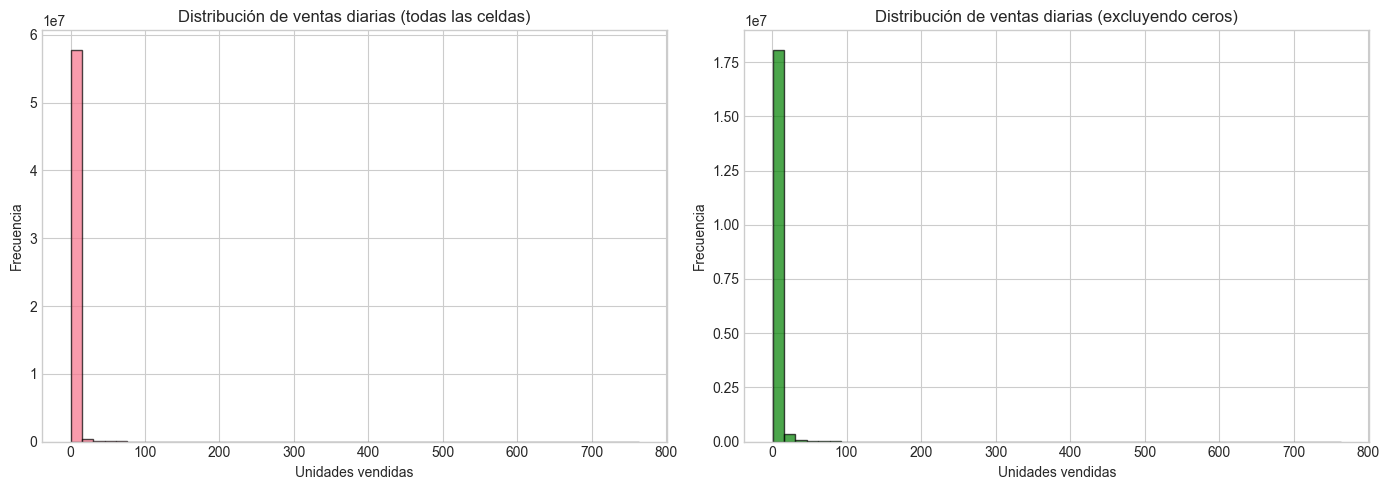

In [25]:
# Distribución de ventas (histograma)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de todas las ventas
ventas_flat = ventas_matriz.flatten()
axes[0].hist(ventas_flat, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Unidades vendidas')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de ventas diarias (todas las celdas)')

# Histograma sin ceros para ver mejor la distribución
ventas_sin_ceros = ventas_flat[ventas_flat > 0]
axes[1].hist(ventas_sin_ceros, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Unidades vendidas')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de ventas diarias (excluyendo ceros)')

plt.tight_layout()
plt.show()

In [26]:
# Ventas totales por serie (producto-tienda)
ventas_por_serie = ITEM_SALES[cols_dias].sum(axis=1)

print("="*60)
print("VENTAS TOTALES POR SERIE (producto-tienda)")
print("="*60)
print(ventas_por_serie.describe())

# Top 10 series con más ventas
print("\nTop 10 series con más ventas:")
top_series = ITEM_SALES.loc[ventas_por_serie.nlargest(10).index, ['id', 'item', 'store', 'category']]
top_series['ventas_totales'] = ventas_por_serie.nlargest(10).values
print(top_series)

VENTAS TOTALES POR SERIE (producto-tienda)
count    30490.00
mean      2154.65
std       5217.23
min         10.00
25%        355.00
50%        848.00
75%       2031.75
max     250502.00
dtype: float64

Top 10 series con más ventas:
                            id               item              store  \
8412   SUPERMARKET_3_090_NYC_3  SUPERMARKET_3_090            Tribeca   
18055  SUPERMARKET_3_586_BOS_2  SUPERMARKET_3_586            Roxbury   
21104  SUPERMARKET_3_586_BOS_3  SUPERMARKET_3_586           Back_Bay   
8908   SUPERMARKET_3_586_NYC_3  SUPERMARKET_3_586            Tribeca   
2314   SUPERMARKET_3_090_NYC_1  SUPERMARKET_3_090  Greenwich_Village   
29755  SUPERMARKET_3_090_PHI_3  SUPERMARKET_3_090      Queen_Village   
17559  SUPERMARKET_3_090_BOS_2  SUPERMARKET_3_090            Roxbury   
20608  SUPERMARKET_3_090_BOS_3  SUPERMARKET_3_090           Back_Bay   
17721  SUPERMARKET_3_252_BOS_2  SUPERMARKET_3_252            Roxbury   
15006  SUPERMARKET_3_586_BOS_1  SUPERMARKET_3_5

In [27]:
# Ventas por categoría
print("="*60)
print("VENTAS POR CATEGORÍA")
print("="*60)

if 'category' in ITEM_SALES.columns:
    ventas_por_categoria = ITEM_SALES.groupby('category')[cols_dias].sum().sum(axis=1).sort_values(ascending=False)
    print(ventas_por_categoria)

VENTAS POR CATEGORÍA
category
SUPERMARKET      45089939
HOME_&_GARDEN    14480670
ACCESORIES        6124800
dtype: int64


In [28]:
# Ventas por tienda
print("="*60)
print("VENTAS POR TIENDA")
print("="*60)

if 'store' in ITEM_SALES.columns:
    ventas_por_tienda = ITEM_SALES.groupby('store')[cols_dias].sum().sum(axis=1).sort_values(ascending=False)
    print(ventas_por_tienda)

VENTAS POR TIENDA
store
Tribeca              11188180
Greenwich_Village     7698216
Roxbury               7214384
Yorktown              6544012
Queen_Village         6427782
Back_Bay              6089330
Harlem                5685475
South_End             5595292
Midtown_Village       5149062
Brooklyn              4103676
dtype: int64


## 9. Conclusiones preliminares

### Hallazgos principales

**Estructura de los datos:**
- **item_sales**: 30,490 series temporales (combinaciones producto-tienda) con 1,913 días de ventas cada una (desde 29/01/2011 hasta 24/04/2016, ~5.2 años)
- **calendar**: 1,913 días con información de día de la semana y eventos especiales
- **item_prices**: 6.9 millones de registros con precios semanales por producto y tienda

**Dimensiones del problema:**
- 3,049 productos únicos
- 10 tiendas en 3 regiones (New York: 4 tiendas, Boston: 3 tiendas, Philadelphia: 3 tiendas)
- 3 categorías: SUPERMARKET, HOME_&_GARDEN, ACCESORIES
- 7 departamentos
- 5 tipos de eventos especiales: SuperBowl, Ramadan, Thanksgiving, NewYear, Easter (solo 26 días de 1,913 tienen evento)

**Calidad de los datos:**
- **item_sales**: Sin valores nulos ni duplicados. Datos completos.
- **calendar**: 1,887 nulos en `event` (esperado: la mayoría de días no tienen evento especial). Sin duplicados.
- **item_prices**: 243,920 nulos en `yearweek` y 213,430 duplicados por combinación item+store_code+yearweek. **Requiere investigación.**
- **Consistencia perfecta** entre tablas: los 1,913 días coinciden, y los 3,049 productos y 10 tiendas están presentes en ambas tablas de sales y prices.

**Observaciones relevantes para forecasting:**
- **Alta proporción de ceros**: El 68.2% de las celdas (producto-tienda-día) tienen 0 ventas. La mediana es 0 y la media es 1.13 unidades. Esto indica datos muy dispersos (sparse) típicos de retail.
- **Distribución muy sesgada**: Las ventas van de 0 a 763 unidades/día con desviación estándar de 3.87. Hay productos de alta rotación y muchos de baja/nula rotación.
- **Categoría dominante**: SUPERMARKET representa el 68.7% de las ventas totales (45M de 65.7M unidades).
- **Variabilidad entre tiendas**: Tribeca (NYC) lidera con 11.2M unidades vs Brooklyn con solo 4.1M (casi 3x diferencia).
- **Productos estrella**: Los top 10 son todos de SUPERMARKET_3. Los productos SUPERMARKET_3_090 y SUPERMARKET_3_586 aparecen en múltiples tiendas como los más vendidos.

### Puntos de atención para siguientes pasos
1. **Investigar duplicados en item_prices**: 213K registros duplicados por item+store_code+yearweek. ¿Precios que cambian dentro de la misma semana?
2. **Investigar nulos en yearweek**: 244K registros sin yearweek. ¿Productos sin fecha de precio asignada?
3. **Estrategia para datos sparse**: Con 68% de ceros, considerar modelos que manejen bien esta característica o agregar a nivel menos granular.
4. **Transformación de formato**: item_sales está en formato wide (columnas d_1 a d_1913). Necesitamos pasarlo a formato long para unirlo con calendar y prices.

### Siguientes pasos
1. **Notebook 02**: Preparar los datos - transformar formato wide a long, investigar y limpiar anomalías en prices, unir las tres tablas
2. **Notebook 03**: Analizar patrones temporales - tendencia, estacionalidad semanal/mensual/anual, efecto de eventos
3. **Notebook 04**: Crear features para el modelo de forecasting